# Inicios


In [1]:
import sys
from pathlib import Path
import pandas as pd
sys.path.insert(0, str(Path.cwd().parents[0] / "src"))
import numpy as np

# Conectando ao phonex


In [2]:
import os
from phoenix.otel import register
import phoenix as px
from openinference.instrumentation.langchain import LangChainInstrumentor

tracer_provider = register(
  project_name="Agente-Criador-Carteira",
  endpoint="https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces",
  auto_instrument=True,
  api_key=os.getenv("PHOENIX_API_KEY")
  
)

LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\phoenix\otel\otel.py:434: UserWarning: Could not infer collector endpoint protocol, defaulting to HTTP.
  warnings.warn("Could not infer collector endpoint protocol, defaulting to HTTP.")
Attempting to instrument while already instrumented


OpenTelemetry Tracing Details
|  Phoenix Project: Agente-Criador-Carteira
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'authorization': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [3]:
from openinference.instrumentation.langchain import LangChainInstrumentor

# Criando roteador de LLM


In [4]:
import nest_asyncio
nest_asyncio.apply()

In [5]:
from pydantic import BaseModel, Field
class Test(BaseModel):
    respostas: str = Field(description="Respostas geradas pelo modelo.")

In [6]:
from groq import AsyncGroq
from pydantic import BaseModel
import json
import asyncio
from typing import Optional, Dict, Any, Union
import logging

# Configurar logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# client = Groq()
client = AsyncGroq()

class RouterGroq:
    def __init__(self, messages: str, model_llm: str, strutured_output: Optional[BaseModel] = None):
        self.messages = messages
        self.strutured_output = strutured_output
        self.model_llm = model_llm
    
    async def llm_structured_groq(self) -> Dict[str, Any]:
        """
        Chama modelo Groq com saída estruturada
        
        """
        
        if self.strutured_output is None:
                raise ValueError(
                    "structured_output precisa estar definido para usar essa função."
                )
        try:
            response = await client.chat.completions.create(
                model=self.model_llm,
                messages=[
                    {"role": "user", "content": self.messages},  
                ],
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "structured_response",
                        "schema": self.strutured_output.model_json_schema(),
                    }
                }
            )
            content = response.choices[0].message.content or "{}"
            return json.loads(content)
        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro ao chamar modelo Groq com saída estruturada: %s", e)
            
    
    async def llm_groq(self) -> str:
        """
        Chama modelo Groq sem saída estruturada
        """
        response = await client.chat.completions.create(
            model=self.model_llm,
            messages=[
                {"role": "user", "content": self.messages},  
            ]
        )
        return response.choices[0].message.content or ""
        


import asyncio

groq_router = RouterGroq(
    messages="Explique a teoria da relatividade de forma simples.",
    model_llm="openai/gpt-oss-120b", 
    strutured_output=Test
     
)

In [7]:
import logging
import os
from typing import Optional

from cerebras.cloud.sdk import AsyncCerebras  # pylint: disable=E0401,E0611
from dotenv import load_dotenv
from pydantic import BaseModel

load_dotenv()

logging.basicConfig(level=logging.INFO)

logger = logging.getLogger(__name__)


class RouterCerebras:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output
        self.client_cerebras = self._get_client()

    def _get_client(self) -> AsyncCerebras:
        api_key = os.getenv("CEREBRAS_API_KEY")
        if not api_key:
            raise ValueError(
                "CEREBRAS_API_KEY não está definida nas variáveis de ambiente."
            )
        return AsyncCerebras(api_key=api_key)

    async def get_response_cerebras_structured_async(self) -> Optional[BaseModel]:
        if self.strutured_output is None:
            raise ValueError(
                "structured_output precisa estar definido para usar essa função."
            )
        try:
            response = await self.client_cerebras.chat.completions.create(
                model=self.model_llm,
                messages=[{"role": "user", "content": self.messages}],
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "structured_response",
                        "schema": self.strutured_output.model_json_schema(),
                    },
                },
            )
            return response.choices[0].message.content  # type:ignore
        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no Cerebras: %s", e)
            raise

    async def get_response_cerebras_async(self) -> str:
        try:
            response = await self.client_cerebras.chat.completions.create(
                model=self.model_llm,
                messages=[{"role": "user", "content": self.messages}],
            )
            return response.choices[0].message.content  # type:ignore
        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no Cerebras: %s", e)
            raise


In [8]:
import logging
from typing import Any, Optional

from dotenv import load_dotenv
from pydantic import BaseModel
from pydantic_ai import Agent  # pylint: disable=E0401,E0611

# pylint: disable=E0401,E0611 #type:ignore;
from pydantic_ai.models.huggingface import HuggingFaceModel  # pylint: disable=E0401,E0611 #type:ignore;

load_dotenv()

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class RouterPydanticAI:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.strutured_output = strutured_output
        self.model_llm = model_llm

    async def llm_structured_pydanticai(self) -> Any:
        """
        Chama modelo HuggingFace via Pydantic AI com saída estruturada
        """
        try:
            if self.strutured_output is None:
                raise ValueError(
                    "structured_output precisa estar definido para usar essa função."
                )

            model = HuggingFaceModel(self.model_llm)
            agent = Agent(model, output_type=self.strutured_output)  # type:ignore

            response = agent.run_sync(self.messages)

            return response

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_pydantic_structured: %s", e)
            raise

    async def llm_pydanticai(self) -> Any:
        """
        Chama modelo HuggingFace via Pydantic AI sem saída estruturada
        """
        try:
            model = HuggingFaceModel(self.model_llm)
            agent = Agent(model)

            response = agent.run_sync(self.messages)

            return response

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_pydanticai: %s", e)
            raise

In [9]:
import json
import logging
import os
import re
from typing import Any, Optional

import httpx
import requests
from pydantic import BaseModel, ValidationError

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%m/%d/%Y %I:%M:%S %p"
)
logger = logging.getLogger(__name__)


class RouterApiNvidia:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output
        self.api_key = os.getenv("NVIDIA_API_KEY")
        self.base_url = "https://integrate.api.nvidia.com/v1/chat/completions"
        self.session = requests.Session()

        if not self.api_key:
            raise ValueError("NVIDIA_API_KEY não encontrada nas variáveis de ambiente.")

    @property
    def _headers(self):
        return {"Authorization": f"Bearer {self.api_key}", "Accept": "application/json"}

    def _extract_json(self, text: str) -> str:
        """Extrai o conteúdo JSON de dentro de blocos de código markdown, se existirem."""
        pattern = r"```json\s*(.*?)\s*```"
        match = re.search(pattern, text, re.DOTALL)
        return match.group(1) if match else text.strip()

    # @retry(stop_max_attempt_number=2, wait_fixed=2000)
    def invoke(self) -> Any:
        """
        Método unificado. Se schema for passado, retorna objeto Pydantic.
        Caso contrário, retorna string.
        """
        payload = {
            "model": self.model_llm,
            "messages": [],
            "temperature": 0.1,  # Baixa temperatura para saídas estruturadas
        }

        if self.strutured_output:
            payload["messages"].append(  # type: ignore
                {
                    "role": "system",
                    "content": f"Respond EXCLUSIVELY in JSON. Schema: {json.dumps(self.strutured_output.model_json_schema())}",
                }
            )

        payload["messages"].append({"role": "user", "content": self.messages})  # type: ignore

        try:
            response = self.session.post(
                self.base_url, headers=self._headers, json=payload, timeout=30
            )
            response.raise_for_status()
            content = response.json()["choices"][0]["message"]["content"]

            if self.strutured_output:
                clean_json = self._extract_json(content)
                return self.strutured_output.model_validate_json(clean_json)

            return content

        except requests.exceptions.RequestException as e:
            logger.error("Erro na chamada da API: Nvidia: %s", e)
            return None
        except (ValidationError, json.JSONDecodeError) as e:
            logger.error("Erro ao processar formato estruturado: %s", e)
            return None

    # @retry(stop_max_attempt_number=2, wait_fixed=2000)
    async def ainvoke(self) -> Any:
        """
        Versão assíncrona do método invoke.
        """
        payload = {"model": self.model_llm, "messages": [], "temperature": 0.1}

        if self.strutured_output:
            payload["messages"].append(  # type: ignore
                {
                    "role": "system",
                    "content": f"Respond EXCLUSIVELY in JSON. Schema: {json.dumps(self.strutured_output.model_json_schema())}",
                }
            )

        payload["messages"].append({"role": "user", "content": self.messages})  # type: ignore

        async with httpx.AsyncClient(timeout=60.0) as client:
            try:
                response = await client.post(
                    self.base_url, headers=self._headers, json=payload
                )
                response.raise_for_status()

                content = response.json()["choices"][0]["message"]["content"]

                if self.strutured_output:
                    clean_json = self._extract_json(content)
                    return self.strutured_output.model_validate_json(clean_json)

                return content

            except httpx.HTTPStatusError as e:
                logger.error("Erro HTTP na chamada da API Nvidia: %s", e)
                return None
            except Exception as e:  # pylint: disable=broad-exception-caught
                logger.error("Erro na chamada da API Nvidia: %s", e)
                return None

In [10]:
import logging
from typing import Any, Optional

#from langchain.chat_models import init_chat_model
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from pydantic import BaseModel

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class RouterNvidia:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output

    async def llm_nvidia(self) -> Optional[str]:
        """
        Chama modelo Nvidia via LangChain
        """
        try:
            #llm = init_chat_model(self.model_llm, model_provider="nvidia")
            llm = ChatNVIDIA(model=self.model_llm)
            response = await llm.ainvoke([{"role": "user", "content": self.messages}])
            return response.content  # type:ignore

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_nvidia: %s", e)
            raise

    async def llm_nvidia_structured(self) -> Optional[Any] | BaseModel:
        """
        Chama modelo Nvidia via LangChain com saída estruturada
        """
        if self.strutured_output is None:
            raise ValueError(
                "structured_output precisa estar definido para usar essa função."
            )

        try:
            llm = ChatNVIDIA(model=self.model_llm)
            llm_strutured = llm.with_structured_output( # type:ignore
                self.strutured_output  # type:ignore
            )

            response = await llm_strutured.ainvoke(  # type:ignore
                [{"role": "user", "content": self.messages}]
            )  # type:ignore
            
            if response is None:
                logger.warning(f"Resposta nula recebida do modelo Nvidia. O modelo {self.model_llm} pode não suportar saída estruturada.")
            
            return response  # type:ignore

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_nvidia_structured: %s", e)
            raise
        
llm_code = RouterNvidia(
    messages="Me explique a teoria da relatividade de forma simples.",
    model_llm="mistralai/mixtral-8x22b-instruct-v0.1",  
    strutured_output=Test
    
)


In [11]:
import logging
import os
from typing import Any, Dict, Optional

from dotenv import load_dotenv
from openai import AsyncOpenAI
from pydantic import BaseModel

load_dotenv()

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%m/%d/%Y %I:%M:%S %p"
)
logger = logging.getLogger(__name__)

client = AsyncOpenAI(
    base_url="https://integrate.api.nvidia.com/v1", api_key=os.getenv("NVIDIA_API_KEY")
)


class RouterOpenaiNvidia:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.strutured_output = strutured_output
        self.model_llm = model_llm

    async def llm_structured_openai_nvidia(self) -> Dict[str, Any] | None:
        """
        Chama modelo nvidia com saída estruturada

        """

        if self.strutured_output is None:
            raise ValueError(
                "structured_output precisa estar definido para usar essa função."
            )
        try:
            response = await client.chat.completions.parse(  # type: ignore[no-matching-overload]
                model=self.model_llm,
                messages=[
                    {"role": "user", "content": self.messages},
                ],
                response_format=self.strutured_output,  # type: ignore
            )
            content = response.choices[0].message.parsed or "{}"
            return content  # type: ignore
        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error(
                "Erro ao chamar modelo Openai Nvidia com saída estruturada: %s", e
            )
        return None

    async def llm_openai_nvidia(self) -> str:
        """
        Chama modelo Openai Nvidia sem saída estruturada
        """
        response = await client.chat.completions.create(  # type: ignore[no-matching-overload]
            model=self.model_llm,
            messages=[
                {"role": "user", "content": self.messages},
            ],
        )
        return response.choices[0].message.content or ""

In [12]:
import logging
from typing import Any, Optional

from langchain_nvidia_ai_endpoints import ChatNVIDIA  # pylint: disable=import-error
from pydantic import BaseModel

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%m/%d/%Y %I:%M:%S %p"
)

logger = logging.getLogger(__name__)


class RouterLangChainNvidia:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output

    # @retry(stop_max_attempt_number=2, wait_fixed=2000)
    async def llm_nvidia(self) -> Optional[str]:
        """
        Chama modelo Nvidia via LangChain
        """
        try:
            llm = ChatNVIDIA(model=self.model_llm)
            response = await llm.ainvoke([{"role": "user", "content": self.messages}])
            return response.content  # type:ignore

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_nvidia: %s", e)
            raise

    # @retry(stop_max_attempt_number=2, wait_fixed=2000)
    async def llm_nvidia_structured(self) -> Optional[Any] | BaseModel:
        """
        Chama modelo Nvidia via LangChain com saída estruturada
        """
        if self.strutured_output is None:
            raise ValueError(
                "structured_output precisa estar definido para usar essa função."
            )

        try:
            llm = ChatNVIDIA(model=self.model_llm)
            llm_strutured = llm.with_structured_output(  # type:ignore
                self.strutured_output  # type:ignore
            )

            response = await llm_strutured.ainvoke(  # type:ignore
                [{"role": "user", "content": self.messages}]
            )  # type:ignore

            if response is None:
                logger.warning(
                    "Resposta nula recebida do modelo Nvidia. O modelo model_llm=%s pode não suportar saída estruturada.",
                    self.model_llm,
                )

            return response  # type:ignore

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_nvidia_structured: %s", e)
            raise

In [13]:
import json
import logging
from typing import Any, Dict, Optional, Union

from pydantic import BaseModel

#from .router_cerebras import RouterCerebras
#from .router_groq import RouterGroq
#from .router_nvidia import RouterNvidia
#from .router_pydantic_ai import RouterPydanticAI

from typing import Any, Optional, Type

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class AllProvidersFailedError(Exception):
    """Exceção levantada quando todos os provedores LLM falham"""


class LlmRouter:
    def __init__(
        self,
        messages: str,
        strutured_output: Optional[Type[BaseModel]] = None,
        **kwargs,
    ):
        self.messages = messages
        self.strutured_output = strutured_output

        # Centraliza os modelos default
        self.models = {
            "Groq": kwargs.get(
                "groq_models",
                [
                    "moonshotai/kimi-k2-instruct-0905",
                    "meta-llama/llama-4-scout-17b-16e-instruct",
                    "openai/gpt-oss-120b",
                ],
            ),
            "Cerebras": kwargs.get(
                "cerebras_models",
                [
                    "qwen-3-235b-a22b-instruct-2507",
                    "gpt-oss-120b",
                    "qwen-3-32b",
                ],
            ),
            "API_Nvidia": kwargs.get(
                "api_nvidia_models",
                [
                    "moonshotai/kimi-k2.5",
                    "nvidia/nemotron-3-nano-30b-a3b",
                    "moonshotai/kimi-k2-instruct",
                    "deepseek-ai/deepseek-v3.2",
                    "moonshotai/kimi-k2-instruct-0905",
                    "meta/llama-4-scout-17b-16e-instruct",
                    "qwen/qwen3-next-80b-a3b-instruct",
                ],
            ),
            "Langchain_nvidia": kwargs.get(
                "api_langchain_nvidia_models",
                [
                    "nvidia/nemotron-4-mini-hindi-4b-instruct",
                ],
            ),
            "Openai_nvidia": kwargs.get(
                "api_openai_nvidia_models",
                [
                    "qwen/qwen3-next-80b-a3b-instruct",
                    "deepseek-ai/deepseek-v3.2",
                    "nvidia/nemotron-3-nano-30b-a3b",
                    "moonshotai/kimi-k2-instruct",
                    "nvidia/nemotron-4-mini-hindi-4b-instruct",
                ],
            ),
        }

    async def _try_provider(
        self, provider_name: str, router_class: Type, method_name: str
    ) -> Any:
        """
        Método genérico para tentar modelos de um provedor específico.
        """
        models = self.models.get(provider_name, [])
        for model in models:
            logger.info("Tentando %s %s", provider_name, model)
            try:
                router = router_class(self.messages, model, self.strutured_output)

                func = getattr(router, method_name)
                result = await func() if asyncio.iscoroutinefunction(func) else func()

                if result:
                    return result
            except Exception as e:  # pylint: disable=broad-exception-caught
                logger.warning("Falha no %s %s %s", provider_name, model, e)
                continue
        return None

    async def llm_router(self) -> Any:
        logger.info("Iniciando roteamento LLM")

        # Configuração dos provedores: (Nome, Classe do Roteador, Método a chamar)
        providers = [
            ("API_Nvidia", RouterApiNvidia, "ainvoke"),
            (
                "Langchain_nvidia",
                RouterLangChainNvidia,
                "llm_nvidia_structured" if self.strutured_output else "llm_nvidia",
            ),
            (
                "Groq",
                RouterGroq,
                "llm_structured_groq" if self.strutured_output else "llm_groq",
            ),
            (
                "Cerebras",
                RouterCerebras,
                (
                    "get_response_cerebras_structured_async"
                    if self.strutured_output
                    else "get_response_cerebras_async"
                ),
            ),
            (
                "Openai_nvidia",
                RouterOpenaiNvidia,
                (
                    "llm_structured_openai_nvidia"
                    if self.strutured_output
                    else "llm_openai_nvidia"
                ),
            ),
        ]

        errors = {}
        for name, cls, method in providers:
            try:
                logger.info("🔄 Rotando para provedor %s", name)
                response = await self._try_provider(name, cls, method)

                if response:
                    logger.info("✅ %s sucesso", name)
                    return response

                errors[name] = "Todos os modelos deste provedor falharam"
            except Exception as e:  # pylint: disable=broad-exception-caught
                errors[name] = str(e)

        raise AllProvidersFailedError(f"Falha total: {errors}")

In [14]:
def tratando_resposta_router_llm(response: Any, model_class=None) -> dict:
    """
    Extrai os campos definidos na model_class (Pydantic) da resposta, independentemente do tipo retornado.
    """
    if hasattr(response, "output"):
        response = response.output

    if model_class and hasattr(response, "dict"):
        return response.dict()

    if isinstance(response, dict):
        if model_class and hasattr(model_class, '__fields__'):
            return {field: response.get(field) for field in model_class.__fields__}
        return response

    if isinstance(response, str):
        try:
            response_json = json.loads(response)
            if model_class and hasattr(model_class, '__fields__'):
                return {field: response_json.get(field) for field in model_class.__fields__}
            return response_json
        except Exception:
            return {}

    if model_class and hasattr(model_class, '__fields__'):
        result = {}
        for field in model_class.__fields__:
            if hasattr(response, field):
                result[field] = getattr(response, field)
        if result:
            return result
    return {}


# Tools

## Tool fundamentos

### Criando graph avaliacao fundamentalista tics

In [18]:
from portfolio_optimizer import TratandoDadosFundamentalistas

from typing import Literal, TypedDict

class StateClassification(TypedDict):
    classification: Literal["Excellent","Good", "Fair", "Poor", "Very Poor"]
    analysis: str
    tic : str
    dados_fundamentalistas: str
    data_inicio: str
    data_fim: str
    avaliacao_analise: str
    description_avaliacao_analise: str
    interacao : int

In [29]:
async def get_data_fundamentalistas(state) -> Dict[str, str]:
    tic = state.get("tic")
    data_inicio = state.get("data_inicio")
    data_fim = state.get("data_fim")
    trat  = TratandoDadosFundamentalistas(tic, data_inicio, data_fim)
    dados = await trat.coleta_dados_fundamentalistas()
    dados_markdow = dados.to_markdown()
    return {
        "dados_fundamentalistas": dados_markdow
    }

In [30]:
from typing import Literal

prompt_analise = f"""
You are a financial analyst specialized in fundamental analysis of stocks. Your task is to evaluate the financial health and investment prospects of companies based on the provided data.

## FUNDAMENTAL DATA
{{fundamentos}}

## FEEDBACK FROM ANALYST
You have received the following feedback from another financial analyst regarding your previous analysis:
{{description_avaliacao_analise}}

<AVAILABLE INDICATORS FOR ANALYSIS>

### Performance Indicators
- **receita_liquida** (net_revenue): Total company revenue after deductions
- **ebitda**: Earnings before interest, taxes, depreciation and amortization
- **lucro_por_acao** (earnings_per_share): Net income divided by number of shares

### Structure and Profitability Indicators
- **alavancagem_financeira** (financial_leverage): Ratio between third-party capital and equity
- **margem_liquida** (net_margin): Percentage of net profit over revenue

### Valuation Indicators
- **preco_lucro** (P/E): Stock price divided by earnings per share
- **preco_vpa** (P/BV): Stock price divided by book value per share

</AVAILABLE INDICATORS FOR ANALYSIS>

<Classification by Company>

For each ticker, provide:
- **Classification**: Excellent | Good | Fair | Poor | Very Poor
- **Rationale**: Objective and concise analysis (maximum 200 characters)

</Classification by Company>

<Classification Criteria>

- **Excellent**: Indicators consistently above sector average, sustainable growth, low debt, high profitability
- **Good**: Majority of positive indicators, solid financial situation with minor points of attention
- **Fair**: Mixed indicators, stable situation but without highlights, some points of concern
- **Poor**: Mostly negative indicators, profitability problems or high debt
- **Very Poor**: Critical indicators, high financial risk, strongly negative trends

</Classification Criteria>

## Respond in Inglish
"""

class TickerLevel(BaseModel):
    classification: Literal["Excellent","Good", "Fair", "Poor", "Very Poor"] = Field(
        description="Ticker classification. Can be 'Excellent', 'Good', 'Fair', 'Poor', or 'Very Poor'. Respond in Inglish."
    )
    analysis: str = Field(
        description="Arguments justifying the classification given to the ticker.",
        max_length=500
    )

In [42]:
tic = "VALE3"
data_inicio = "2022-01-01"
data_fim = "2023-01-01"
trat  = TratandoDadosFundamentalistas(tic, data_inicio, data_fim)
dados = await trat.coleta_dados_fundamentalistas()
dados_markdow = dados.to_markdown()

In [45]:
promp_formated = prompt_analise.format(fundamentos=dados_markdow, description_avaliacao_analise="")


lllm_router = LlmRouter(
    messages=promp_formated,
    strutured_output=TickerLevel
)
response = await lllm_router.llm_router()

INFO:__main__:Iniciando roteamento LLM
INFO:__main__:🔄 Rotando para provedor API_Nvidia
INFO:__main__:Tentando API_Nvidia moonshotai/kimi-k2.5
INFO:httpx:HTTP Request: POST https://integrate.api.nvidia.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:✅ API_Nvidia sucesso


In [46]:
response

TickerLevel(classification='Good', analysis='Extremely attractive valuation with P/E below 3.7x and P/BV near 1.9x. Excellent debt profile with Net Debt/EBITDA below 0.4x and robust net margins above 40%. Strong operating cash generation despite declining revenue and EBITDA trend over consecutive quarters. Negative cash changes indicate working capital needs or investments. Solid financial health with manageable leverage.')

In [47]:
def tratando_resposta_router_llm(response: Any, model_class=None) -> dict:
    """
    Extrai os campos definidos na model_class (Pydantic) da resposta, independentemente do tipo retornado.
    """
    if hasattr(response, "output"):
        response = response.output

    if model_class and hasattr(response, "dict"):
        return response.dict()

    if isinstance(response, dict):
        if model_class and hasattr(model_class, '__fields__'):
            return {field: response.get(field) for field in model_class.__fields__}
        return response


    if isinstance(response, str):
        try:
            response_json = json.loads(response)
            if model_class and hasattr(model_class, '__fields__'):
                return {field: response_json.get(field) for field in model_class.__fields__}
            return response_json
        except Exception:
            return {}

    if model_class and hasattr(model_class, '__fields__'):
        result = {}
        for field in model_class.__fields__:
            if hasattr(response, field):
                result[field] = getattr(response, field)
        if result:
            return result
    return {}


In [48]:
async def analista_fundamentalista(state) -> Dict[Any, Any]:
    data = state.get("dados_fundamentalistas")
    
    description_avaliacao_analise = state.get("description_avaliacao_analise")
    
    prompt_formatted = prompt_analise.format(fundamentos = data, 
                                             description_avaliacao_analise=description_avaliacao_analise)
    llm = LlmRouter(
        prompt_formatted,
        strutured_output= TickerLevel
    )
    
    response= await llm.llm_router()
    
    response_trat = tratando_resposta_router_llm(response, TickerLevel)
    
    return {"classification": response_trat.get("classification"), "analysis": response_trat.get("analysis")}
    
    

In [49]:
prompt_avaliador = f"""
You are a senior financial analyst with expertise in quality assurance and validation of financial analyses. Your task is to critically evaluate the classification and analysis provided by another analyst.

## ORIGINAL FUNDAMENTAL DATA
{{fundamentos}}

## ANALYST'S CLASSIFICATION TO EVALUATE
{{classification}}

## ANALYST'S ANALYSIS TO EVALUATE
{{analise}}

<AVAILABLE INDICATORS>

### Performance Indicators
- **receita_liquida** (net_revenue): Total company revenue after deductions
- **ebitda**: Earnings before interest, taxes, depreciation and amortization
- **lucro_por_acao** (earnings_per_share): Net income divided by number of shares

### Structure and Profitability Indicators
- **alavancagem_financeira** (financial_leverage): Ratio between third-party capital and equity
- **margem_liquida** (net_margin): Percentage of net profit over revenue

### Valuation Indicators
- **preco_lucro** (P/E): Stock price divided by earnings per share
- **preco_vpa** (P/BV): Stock price divided by book value per share

</AVAILABLE INDICATORS>

<EVALUATION CRITERIA>

Accuracy of Classification
Verify if the classification (Excellent/Good/Fair/Poor/Very Poor) is consistent with the fundamental indicators:
</EVALUATION CRITERIA>

</EVALUATION OUTPUT>

Be rigorous but fair in your evaluation. If the analyst's work is sound, acknowledge it. If there are issues, be specific about what needs improvement and why.

## Respond in Inglish
"""

class SeniorAvaliador(BaseModel):
    """Specific issue found in the analysis."""
    
    avaliacao_analise: Literal[True, False] = Field(
        description="Evaluation of the analyst's analysis, indicating if it is True (that a good analisy) or False (that is a bad analisy)."
    )
    
    description_avaliacao_analise: str = Field(
        description="Detailed description of the avaliation. Why you think that.",
        max_length=500
    )
    


In [50]:
async def avaliador_analista_fundamentalista(state) -> Dict[Any, Any]:
    data = state.get("dados_fundamentalistas")
    classification = state.get("classification")
    analise = state.get("analysis")
    interacao = state.get("interacao", 0)
    
    prompt_formatted = prompt_avaliador.format(
        fundamentos = data,
        classification= classification,
        analise= analise
    )
    
    llm = LlmRouter(
        prompt_formatted,
        strutured_output= SeniorAvaliador
    )
    
    response= await llm.llm_router()
    
    response_trat = tratando_resposta_router_llm(response, SeniorAvaliador)
    
    new_interacao = interacao + 1
    
    return {
        "avaliacao_analise": response_trat.get("avaliacao_analise"),
        "description_avaliacao_analise": response_trat.get("description_avaliacao_analise"),
        "interacao": new_interacao
    }

In [51]:
def should_continue(state) -> Literal["END", "analise_fundamentalista"]:
    avaliacao = state.get("avaliacao_analise")
    interacao = state.get("interacao")
    if avaliacao or interacao >=3:
        return "END"
    return "analise_fundamentalista"
    

In [52]:
from langgraph.graph import END, StateGraph, START


graph = StateGraph(StateClassification)
graph.add_node("coleta_fundamentalistas", get_data_fundamentalistas)


graph.add_node("analise_fundamentalista", analista_fundamentalista)
graph.add_node("avaliacao_analise", avaliador_analista_fundamentalista)

graph.set_entry_point("coleta_fundamentalistas")

graph.add_edge(START, "coleta_fundamentalistas")
graph.add_edge("coleta_fundamentalistas", "analise_fundamentalista")
graph.add_edge("analise_fundamentalista", "avaliacao_analise")
graph.add_conditional_edges("avaliacao_analise", should_continue, {
    "END": END,
    "analise_fundamentalista": "analise_fundamentalista"
})

graph_build = graph.compile()


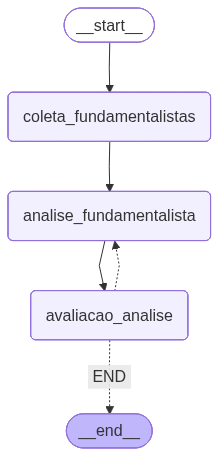

In [53]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import display, Image
import nest_asyncio

nest_asyncio.apply()

display(Image(graph_build.get_graph().draw_mermaid_png()))

In [54]:
data_inicio = "2023-01-01"  
data_fim = "2025-01-31"
response = await graph_build.ainvoke(
            StateClassification(
                {
                    "tic": 'VALE3',
                    "data_inicio": data_inicio,
                    "data_fim": data_fim,
                    "avaliacao_analise": "",
                    "description_avaliacao_analise": "",
                    "interacao": 0,
                }
            )
        )

INFO:__main__:Iniciando roteamento LLM
INFO:__main__:🔄 Rotando para provedor API_Nvidia
INFO:__main__:Tentando API_Nvidia moonshotai/kimi-k2.5
ERROR:__main__:Erro na chamada da API Nvidia: 
INFO:__main__:Tentando API_Nvidia nvidia/nemotron-3-nano-30b-a3b
INFO:httpx:HTTP Request: POST https://integrate.api.nvidia.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:✅ API_Nvidia sucesso
INFO:__main__:Iniciando roteamento LLM
INFO:__main__:🔄 Rotando para provedor API_Nvidia
INFO:__main__:Tentando API_Nvidia moonshotai/kimi-k2.5
ERROR:__main__:Erro na chamada da API Nvidia: 
INFO:__main__:Tentando API_Nvidia nvidia/nemotron-3-nano-30b-a3b
INFO:httpx:HTTP Request: POST https://integrate.api.nvidia.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:✅ API_Nvidia sucesso


In [55]:
response

{'classification': 'Good',
 'analysis': "Revenue and EBITDA show steady growth, EPS remains robust, leverage stable around 2.3‑2.5, net margin around 20‑30% historically but currently low (~19‑23%). P/E and P/BV are moderate, indicating reasonable valuation. Operating cash flow is generally positive with some volatility, debt/EBITDA under 0.7, suggesting manageable leverage. Overall financial health is solid but margins are modest, preventing an 'Excellent' rating.",
 'tic': 'VALE3',
 'dados_fundamentalistas': '|    |   receita_liquida |   ebitda |   lucro_por_acao | datas               | tic   |   alavancagem_financeira |   margem_liquida |   preço_lucro |   preço_vpa |   fluxo_caixa_operacional |   divida_liquida_ebitda |   aumento_reducao_caixa_equivalentes |\n|---:|------------------:|---------:|-----------------:|:--------------------|:------|-------------------------:|-----------------:|--------------:|------------:|--------------------------:|------------------------:|----------

#### Run all tics

In [33]:
import asyncio
import time
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

"""tics = ["VALE3", "PETR4", "ITUB4", "BBDC4", "ABEV3", 
        "MGLU3", "BBAS3", "GGBR4", "RENT3", "LREN3",
        "PSSA3", "BBSE3", "BRAP4", "VIVT3"]"""

async def _invoke_tic(tic: str, data_inicio: str = "2023-01-01", data_fim: str = "2025-01-01"):
    try:
        start = time.time()
        logger.info(f"🚀 Iniciando {tic}")
        
        result = await graph_build.ainvoke(
            StateClassification({
                "tic": tic,
                "data_inicio": data_inicio,
                "data_fim": data_fim,
                "avaliacao_analise": "",
                "description_avaliacao_analise": "",
                "interacao": 0,
            })
        )
        
        elapsed = time.time() - start
        logger.info(f"✅ {tic} concluído em {elapsed:.2f}s")
        return result
        
    except Exception as e:
        logger.error(f"❌ Erro ao processar {tic}: {e}")
        return None

async def run_all_tics(tics, data_inicio: str = "2023-01-01", data_fim: str = "2025-01-01"):
    start_total = time.time()
    
    tasks = [_invoke_tic(tic, data_inicio, data_fim) for tic in tics]
    results_list = await asyncio.gather(*tasks, return_exceptions=True)
    
    elapsed_total = time.time() - start_total
    logger.info(f"⏱️  Tempo total: {elapsed_total:.2f}s")
    
    return dict(zip(tics, results_list))


# Executar
"""results_tics = await run_all_tics(
    tics
    #list_tics[:10]
    )
results_tics"""

'results_tics = await run_all_tics(\n    tics\n    #list_tics[:10]\n    )\nresults_tics'

### Criando pesos carteira

In [56]:
from typing import TypedDict, Dict, List
class StateCarteira(TypedDict):
    tickers_weights: Dict[str, float]
    justification : str 
    analise_avaliador_weights: str
    avaliacao_acoes : str
    correlacao_acoes : str
    interacao : int
    soma_weights_error : str
    tics: List[str]
    tics_error : str
    
    
class CarteiraWeights(BaseModel):
    tickers_weights: Dict[str, float] = Field(description="Tickers and their respective weights. The sum of the weights should be 100.")
    justification : str = Field(description="Justification about the allocation. Explain why the weights of each asset are chosen.",
                                max_length=1000)

In [57]:
PROMPT_CRIANDO_CARTEIRA = f"""
You are a **quantitative financial consultant specialized in portfolio optimization**, 
with a focus on the Brazilian equities market.

Your goal is to analyze the data provided and propose the **optimal allocation weights (%)** 
for each correlation, and fundamental quality. The sum of all weights **must be exactly 100%**

**Qualitative Asset Classification:**
{{classificacoes_acoes}}

## 📌 AVAILABLE DATA

<Qualitative Asset Classification>
Each asset has received a fundamental classification according to the following levels:

- **Excellent** — consistently above-average sector indicators; strong growth; low leverage; high profitability.
- **Good** — mostly solid indicators; few points of concern.
- **Fair** — mixed indicators; moderate performance; meaningful points of attention.
- **Poor** — predominantly weak indicators; problematic leverage or profitability.
- **Very Poor** — critical indicators; high deterioration risk.

<Correlation Matrix of Returns>
Use the correlation matrix to measure systemic risk, identify risk clusters, 
and avoid non-obvious concentration.
{{matriz_correlacao}}

</Correlation Matrix of Returns>

{{recomendacao}}

<OPTIMIZATION OBJECTIVES>

1. **Maximize the return/risk balance** (qualitative + quantitative).
2. **Maintain effective diversification**, avoiding excessive concentration.
3. **Prioritize assets with superior classification** (Excellent > Good > Fair).
4. **Minimize weighted correlations** between selected assets.
5. **Avoid low-quality assets**, limiting **Poor + Very Poor to a maximum of 5% combined**, if included at all.

</OPTIMIZATION OBJECTIVES>

<ALLOCATION CONSTRAINTS>

- The sum of all weights **must be exactly 100%**.
- **Minimum weight** per included asset: **5%**.
- **Maximum weight** per asset: **20%**.
- Among assets of the same class (Excellent, Good, Fair), prioritize those with the best **risk/return tradeoff**.
</ALLOCATION CONSTRAINTS>

</REQUIRED RESPONSE FORMAT>
The justification must relate:
- fundamental quality,
- correlation within the portfolio,
- risk/return profile,
- the asset’s role in diversification.
</REQUIRED RESPONSE FORMAT>

<PORTFOLIO RISK ANALYSIS>
Include the following:
- achieved diversification and presence of clusters,
- weighted average correlation,
- total exposure to Fair / Poor / Very Poor,
- main risks of the portfolio,
- how the proposed allocation mitigates these risks.

</PORTFOLIO RISK ANALYSIS>

{{tics_error}}

{{soma_pesos_error}}


<⚠️ WEIGHT CALCULATION VERIFICATION:**>
After creating your allocation, you MUST show:
```
Verification:
Asset 1: XX.XX%
Asset 2: XX.XX%
Asset 3: XX.XX%
...
Asset N: XX.XX%
───────────────
SUM:    100.00% ✓
```
**If your sum ≠ 100.00%:**
1. Calculate the error: difference = 100.00% - current_sum
2. Distribute the difference proportionally across all assets
3. Recalculate until sum = 100.00%
4. Never submit a portfolio that doesn't sum to exactly 100%

</⚠️ WEIGHT CALCULATION VERIFICATION:**>

<FINAL CHECKLIST>
Before submitting, verify:

Total weight = exactly 100.00%
Each asset has 5% ≤ weight ≤ 20%
Poor + Very Poor assets ≤ 5% combined
Weighted average correlation is calculated
Each asset selection is justified
All previous feedback points are addressed
Risk analysis is comprehensive
Response is in English
</FINAL CHECKLIST>

"""

In [58]:
RECOMENDACAO_SENIOR = """<PREVIOUS PORTFOLIO EVALUATION & RECOMMENDATIONS>
A senior analyst has reviewed a previous allocation attempt and provided the following feedback.
**YOU MUST INCORPORATE THESE RECOMMENDATIONS** into your new allocation proposal.

{recomendacao}

**CRITICAL**: Address each identified issue and implement suggested improvements in your allocation.

</PREVIOUS PORTFOLIO EVALUATION & RECOMMENDATIONS>"""

In [59]:
async def analista_criador_carteira(state):
    
    correlacao = state.get("correlacao_acoes")
    
    dados_markdown = state.get("avaliacao_acoes")
    
    analise_avaliador_weights = state.get("analise_avaliador_weights")
    
    soma_pesos_error = state.get("soma_weights_error")
    
    tics_error = state.get("tics_error")
    
    recomendacao = (
    RECOMENDACAO_SENIOR.format(recomendacao=analise_avaliador_weights)
    if analise_avaliador_weights
    else "")
        
    soma_pesos_error = soma_pesos_error or ""
        
    tics_error = tics_error or ""
        
    PROMPT_CRIANDO_CARTEIRA_FORMATED = PROMPT_CRIANDO_CARTEIRA.format(
                                    classificacoes_acoes=dados_markdown,
                                    matriz_correlacao=correlacao,
                                    recomendacao=recomendacao,
                                    soma_pesos_error=soma_pesos_error,
                                    tics_error= tics_error
                                        )
        
    llm = LlmRouter(PROMPT_CRIANDO_CARTEIRA_FORMATED, CarteiraWeights)
    
    response = await llm.llm_router()
    
    response_trat = tratando_resposta_router_llm(response, CarteiraWeights)
        
    return {
            "tickers_weights": response_trat.get("tickers_weights"),
            "justification": response_trat.get("justification")
        }

In [60]:
PROMPT_AVALIADOR_PESOS_CARTEIRA = f"""

You are a **senior portfolio review analyst and risk management specialist**, 
with deep expertise in Brazilian equities markets and quantitative portfolio construction.

Your mission is to **critically evaluate** a proposed portfolio allocation, examining whether 
it genuinely adheres to stated optimization objectives, constraints, and best practices 
in portfolio management. The sum of all weights **must be exactly 100%**

{{soma_pesos_error}}

<REQUIRED RESPONSE FORMAT>
The justification must relate:
- fundamental quality,
- correlation within the portfolio,
- risk/return profile,
- the asset’s role in diversification.
</REQUIRED RESPONSE FORMAT>

<PORTFOLIO RISK ANALYSIS>
Include the following:
- achieved diversification and presence of clusters,
- weighted average correlation,
- total exposure to Fair / Poor / Very Poor,
- main risks of the portfolio,
- how the proposed allocation mitigates these risks.

</PORTFOLIO RISK ANALYSIS>

<FINAL CHECKLIST>
Before submitting, verify:

Total weight = exactly 100.00%
Each asset has 5% ≤ weight ≤ 20%

## INPUTS FOR EVALUATION

<Proposed Portfolio Allocation>
{{alocacao_proposta}}
</Proposed Portfolio Allocation>

<Justified of Proposed Portfolio Allocation>
{{justificativa}}
</Justified of Proposed Portfolio Allocation>

<Original Qualitative Asset Classification>
{{classificacoes_acoes}}
</Original Qualitative Asset Classification>

<Original Correlation Matrix>
{{matriz_correlacao}}
</Original Correlation Matrix>

<Stated Optimization Objectives>
1. Maximize return/risk balance (qualitative + quantitative)
2. Maintain effective diversification
3. Prioritize assets with superior classification
4. Minimize weighted correlations
5. Limit Poor + Very Poor assets to maximum 5% combined
</Stated Optimization Objectives>

<Stated Constraints>
- Total allocation must equal 100%
- Minimum weight per asset: 5%
- Maximum weight per asset: 20%
- Prioritize best risk/return within same quality class
</Stated Constraints>

---

## 🔍 EVALUATION DIMENSIONS

### 1. **CONSTRAINT COMPLIANCE** (Pass/Fail)
Verify mathematically:
- [ ] Does allocation sum to exactly 100%?
- [ ] Are all individual weights between 5% and 20%?
- [ ] Is Poor + Very Poor exposure ≤ 5%?
- [ ] Are there any calculation errors?

**Score: X/4 constraints met**

---

### 2. **OPTIMIZATION QUALITY** (Score: 0-10)

#### 2.1 Quality Prioritization
- What % is allocated to Excellent assets?
- What % is allocated to Good assets?
- What % is allocated to Fair assets?
- Is there excessive weight on lower-quality assets?
- Are higher-quality assets genuinely prioritized?

**Score: __/10**

#### 2.2 Diversification Effectiveness
- How many assets are included?
- Is concentration excessive (e.g., 3 assets > 60% combined)?
- Are there correlation clusters not addressed?
- Calculate Herfindahl-Hirschman Index (HHI) if applicable
- Are sector/industry concentrations mentioned and managed?

**Score: __/10**

#### 2.3 Correlation Management
- What is the weighted average correlation of the portfolio?
- Are highly correlated assets (>0.7) over-represented?
- Does the allocation genuinely reduce systemic risk?
- Are uncorrelated/negatively correlated assets utilized?

**Score: __/10**

---

### 3. **JUSTIFICATION COHERENCE** (Score: 0-10)

For each allocated asset, verify if justification includes:
- [ ] Explicit reference to fundamental quality classification
- [ ] Discussion of correlation role in portfolio context
- [ ] Clear risk/return rationale
- [ ] Diversification contribution explanation

Are justifications:
- Specific and data-driven?
- Generic and repetitive?
- Contradictory to the allocation itself?

**Score: __/10**

---

### 4. **RISK ANALYSIS DEPTH** (Score: 0-10)

Evaluate if the risk analysis addressed:
- [ ] Diversification level achieved
- [ ] Presence and impact of correlation clusters
- [ ] Weighted average correlation calculation
- [ ] Total exposure to Fair/Poor/Very Poor
- [ ] Main portfolio risks identified
- [ ] Mitigation strategies explained

Is the risk analysis:
- Comprehensive and quantitative?
- Superficial or qualitative only?
- Missing critical risk factors?

**Score: __/10**

---

## 📋 REQUIRED OUTPUT FORMAT

### **EXECUTIVE SUMMARY**
[2-3 sentences: Overall assessment of portfolio quality]

---

### **CONSTRAINT COMPLIANCE CHECK**
| Constraint | Met? | Details |
|------------|------|---------|
| Sum = 100% | ✓/✗ | Actual: __% |
| Min 5% per asset | ✓/✗ | Violations: __ |
| Max 30% per asset | ✓/✗ | Violations: __ |
| Poor+Very Poor ≤5% | ✓/✗ | Actual: __% |

**Result: PASS / FAIL**

---

### **QUANTITATIVE SCORES**

| Dimension | Score | Justification |
|-----------|-------|---------------|
| Quality Prioritization | __/10 | |
| Diversification | __/10 | |
| Correlation Management | __/10 | |
| Justification Coherence | __/10 | |
| Risk Analysis Depth | __/10 | |
| **OVERALL SCORE** | **__/50** | |

<EVALUATION PRINCIPLES>

- **Be objective and evidence-based**: Use calculations, not opinions
- **Be constructive, not destructive**: Highlight what works AND what doesn't
- **Be specific**: "Correlation too high" → "Weighted avg correlation of 0.82 exceeds optimal range of 0.3-0.5"
- **Be fair**: Acknowledge trade-offs and constraints in portfolio construction
- **Be actionable**: Every criticism should have a clear improvement path
</EVALUATION PRINCIPLES>

<CHECK TICKERS SELECTED>

⚠️ MANDATORY VALIDATION

**AVAILABLE TICKERS:**
{{tickers_disponiveis}}

**RULES:**
- Use ONLY tickers from the list above
- Verify exact spelling (e.g., PETR4.SA, not PETR3.SA)
- Invalid tickers will be rejected

</CHECK TICKERS SELECTED>

---

<FINAL CHECKLIST>
Before submitting, verify:

 Total weight = exactly 100.00%
 Check if the tics are corrects.
 Each asset has 5% ≤ weight ≤ 20%
 Poor + Very Poor assets ≤ 5% combined
 Weighted average correlation is calculated
 Each asset selection is justified
 All previous feedback points are addressed
 Risk analysis is comprehensive
 Response is in English
</FINAL CHECKLIST>
"""

In [61]:
async def analista_avaliador_peso_carteira(state):
    
    alocacao_proposta = state.get("tickers_weights")
    
    justificativa = state.get("justification")
    
    correlacao = state.get("correlacao_acoes")
    
    dados_markdown = state.get("avaliacao_acoes")
    
    interacao = state.get("interacao", 0)
    
    soma_pesos_error = state.get("soma_weights_error")
    
    tics_disponiveis = state.get("tics")
    
    tics_disponiveis_sa = [tic if tic.endswith(".SA") else tic + ".SA" for tic in tics_disponiveis]
    
    soma_pesos_error = soma_pesos_error or ""
    
    PROMPT_AVALIADOR_PESOS_CARTEIRA_FORMATTED = PROMPT_AVALIADOR_PESOS_CARTEIRA.format(
                                                alocacao_proposta=alocacao_proposta,
                                                justificativa= justificativa,
                                                classificacoes_acoes=dados_markdown,
                                                matriz_correlacao=correlacao,
                                                soma_pesos_error = soma_pesos_error,
                                                tickers_disponiveis = tics_disponiveis_sa
    )
    
    llm = LlmRouter(
        PROMPT_AVALIADOR_PESOS_CARTEIRA_FORMATTED,   
    )
    response= await llm.llm_router()
    
    new_interacao = interacao + 1
    
    return {"analise_avaliador_weights" : response,
            "interacao": new_interacao}
    
    

In [62]:
"""async def verify_weight_sum(state):

    Verifies if the sum of ticker weights totals 100%.
    
    Args:
        state: State containing the ticker weights
        
    Returns:
        dict: Error message if sum is not 100%, None otherwise

    weights = state.get("tickers_weights")
    
    # Calculate the total sum of weights
    total_sum = sum(weights.values())
    
    logger.info(f"Total sum of weights: {total_sum}")
    
    # Check if sum is different from 100% (with tolerance for rounding errors)
    if abs(total_sum - 100) > 0.01:
        return {
            "soma_weights_error": f<🚨 PREVIOUS ALLOCATION ERROR DETECTED:**>
                                    Your last attempt produced a total weight of **{total_sum:.2f}%** instead of 100.00%.
                                    This is an error of **{abs(total_sum - 100.0):.2f} percentage points**.
                                    </🚨 PREVIOUS ALLOCATION ERROR DETECTED:**>
                                    
                                            }
    
    return {"soma_weights_error": None}  """
    

def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados


In [63]:
async def verify_weight_sum(state):
    """
    Verifica e normaliza a soma dos pesos do portfólio.
    """
    weights = state.get("tickers_weights")
    
    # Verificação de entrada
    if not weights:
        return {
            "soma_weights_error": "⚠️ Nenhum peso de ticker fornecido.",
            "tickers_weights": {}
        }
    
    # Normalizar pesos
    new_pesos = normalizar_pesos(weights)
    
    # CORREÇÃO: Adicionar () para chamar o método
    sum_new_pesos = sum(new_pesos.values())
    
    # Verificar se ainda há erro após normalização
    if abs(sum_new_pesos - 100) > 0.01:
        erro_percentual = abs(sum_new_pesos - 100.0)
        
        return {
            "soma_weights_error": f"""<🚨 PREVIOUS ALLOCATION ERROR DETECTED>
            Your last attempt produced a total weight of **{sum_new_pesos:.2f}%** instead of 100.00%.
            This is an error of **{erro_percentual:.2f} percentage points**.

            **Original weights:** {weights}
            **After normalization:** {new_pesos}
            **Sum after normalization:** {sum_new_pesos:.4f}%

            Please review and provide corrected weights.
            </🚨 PREVIOUS ALLOCATION ERROR DETECTED>""",
                        "tickers_weights": weights  # Retorna original em caso de erro
        }
    
    # Sucesso
    logger.info(f"✓ Pesos normalizados com sucesso: soma = {sum_new_pesos:.4f}%")
    return {
        "soma_weights_error": None,
        "tickers_weights": new_pesos
    }

In [64]:
def verifica_tics_selecionados(state):
    
    tics_pesos  = state.get("tickers_weights")
    
    tics_possiveis = state.get("tics")
    
    tics_possiveis_sem_sa = [tic.split(".")[0] for tic in tics_possiveis]
    
    tics_pesos_sem_sa = [tic.split(".")[0] for tic in tics_pesos.keys()]
    
    tics_modelo = list(tics_pesos_sem_sa)
    
    tics_comparados = [tic for tic in tics_modelo if tic not in tics_possiveis_sem_sa]

    if tics_comparados:
        tics_comparados_s = ",".join(tics_comparados)
        logger.info(f"Os seguintes tickers não foram encontrados: {tics_comparados_s}")
        return {"tics_error": f"""
                                <🚨 PREVIOUS TICKER SELECTION ERROR DETECTED:**>
                                
                                Your last attempt produced one tickers error.
        
                                The following tickers were not found: {tics_comparados_s}

                                Please ensure that:
                                - Ticker symbols are spelled correctly
                                - Assets exist in the database
                                - There are no extra spaces or invalid character 
                                
                                Please try again with valid tickers.
                                
                                </🚨 PREVIOUS TICKER SELECTION ERROR DETECTED:**>
                                """}
        
        
    return {"tics_error": None}
    

In [65]:
def should_continue(state) -> Literal["END", "analista_avaliador_peso_carteira"]:
    
    MAX_ITERATIONS = 3
    
    #TARGET_SUM = 100
    
    interacao = state.get("interacao")
    
    #pesos = state.get("tickers_weights")
    
    tics_error = state.get("tics_error")
    
    #sum_pesos = sum(pesos.values())
    
    max_iterations_reached = interacao >= MAX_ITERATIONS
    
    #weights_are_valid = sum_pesos == TARGET_SUM
    
    no_ticker_errors = tics_error is None
    
    if max_iterations_reached and no_ticker_errors:
        return "END"
    return "analista_avaliador_peso_carteira"

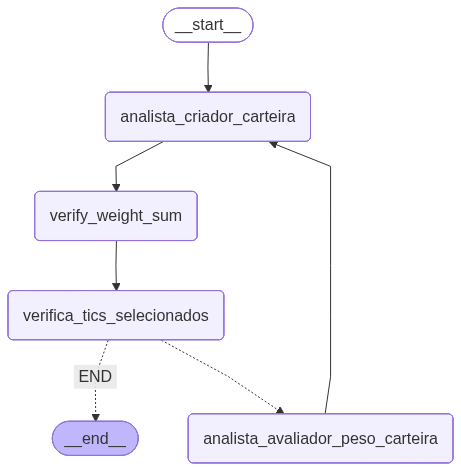

In [66]:
graph_weights = StateGraph(StateCarteira)

graph_weights.add_node("analista_criador_carteira", analista_criador_carteira)

graph_weights.add_node("verify_weight_sum", verify_weight_sum)

graph_weights.add_node("verifica_tics_selecionados", verifica_tics_selecionados)

graph_weights.add_node("analista_avaliador_peso_carteira", analista_avaliador_peso_carteira)

graph_weights.set_entry_point("analista_criador_carteira")

graph_weights.add_edge("analista_criador_carteira", "verify_weight_sum")

graph_weights.add_edge("verify_weight_sum", "verifica_tics_selecionados")

graph_weights.add_edge("analista_avaliador_peso_carteira", "analista_criador_carteira")

graph_weights.add_conditional_edges("verifica_tics_selecionados", should_continue, {
    "analista_avaliador_peso_carteira": "analista_avaliador_peso_carteira",
    "END": END
})

graph_weights_build = graph_weights.compile()

graph_weights_build

In [67]:
import yfinance as yf
import pandas as pd
from typing import List

def correlacao(tics:List[str]):
        tics_yf = [tic + ".SA" for tic in tics]

        df = yf.download(tics_yf, start="2023-01-01", end="2025-01-01", interval="1mo")["Close"]
        returns = df.pct_change()[4:]
        # Calcula a matriz de correlação
        correlacao = returns.corr()

        return correlacao.to_markdown()

In [ ]:
def transformando_data_frame_para_markdown(results):
    try:
        results_pd = pd.DataFrame.from_dict(results).T
    except Exception as e:
        results_pd = pd.DataFrame.from_dict(results, orient="index").T
    dados_markdown = results_pd.loc[:, ["classification", "analysis"]].reset_index().rename(columns={"index": "tic"}).to_markdown()
    return dados_markdown




In [70]:
with open("../data/results_tics.json", "r") as f:
    results_tics = json.load(f)

In [ ]:
results_tics

In [73]:
classificacao_boa = [
   "good",
   "excellent",
   #"fair"
]

response = {k: v for k, v in results_tics.items() if v is not None and v.get('classification').lower() in classificacao_boa}

In [76]:
response_markdown = transformando_data_frame_para_markdown(response)
corr_tics = correlacao(list(response.keys()))

[*********************100%***********************]  38 of 38 completed


In [77]:
tics = list(response.keys())

In [78]:
response_pesos = await graph_weights_build.ainvoke(
    StateCarteira({
    "justification" : "",
    "avaliacao_acoes": response_markdown,
    "correlacao_acoes": corr_tics,
    "interacao" : 0,
    "tics": tics
    }))

INFO:__main__:Iniciando roteamento LLM
INFO:__main__:🔄 Rotando para provedor API_Nvidia
INFO:__main__:Tentando API_Nvidia moonshotai/kimi-k2.5
ERROR:__main__:Erro na chamada da API Nvidia: 
INFO:__main__:Tentando API_Nvidia nvidia/nemotron-3-nano-30b-a3b
ERROR:__main__:Erro na chamada da API Nvidia: 
INFO:__main__:Tentando API_Nvidia moonshotai/kimi-k2-instruct
INFO:httpx:HTTP Request: POST https://integrate.api.nvidia.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:✅ API_Nvidia sucesso
INFO:__main__:✓ Soma final: 100.0000%
INFO:__main__:✓ Pesos normalizados com sucesso: soma = 100.0000%
INFO:__main__:Iniciando roteamento LLM
INFO:__main__:🔄 Rotando para provedor API_Nvidia
INFO:__main__:Tentando API_Nvidia moonshotai/kimi-k2.5
ERROR:__main__:Erro na chamada da API Nvidia: 
INFO:__main__:Tentando API_Nvidia nvidia/nemotron-3-nano-30b-a3b
INFO:httpx:HTTP Request: POST https://integrate.api.nvidia.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:✅ API_Nvidia sucesso
INFO:_

In [79]:
response_pesos

{'tickers_weights': {'ALLD3.SA': 12.08791208791209,
  'ALOS3.SA': 10.989010989010989,
  'ALPA3.SA': 9.89010989010989,
  'ANIM3.SA': 7.692307692307693,
  'ASAI3.SA': 6.593406593406594,
  'COGN3.SA': 10.989010989010989,
  'DIRR3.SA': 12.08791208791209,
  'FIQE3.SA': 13.186813186813188,
  'PSSA3.SA': 5.4945054945054945,
  'TRIS3.SA': 5.4945054945054945,
  'WEGE3.SA': 5.4945054945054945},
 'justification': 'Each asset selected carries the required minimum ‘Good’ rating (no Fair or Poor) and a weight between 5 % and 12 %, satisfying all hard allocation constraints while materially reducing the concentration and high-correlation issues flagged in the prior review. The 11-name mix keeps the HHI at only 0.095 (well below the previous 0.13) and drops the portfolio-weighted correlation to c. 0.45 while balancing valuation attractiveness (P/E ≤12 × for almost every holding) with operational quality and positive cash-flow traction. Sectoral exposures are now topped by industrials, financial-servic

In [80]:
sum(response_pesos['tickers_weights'].values())

100.0

In [81]:
tics_selecionados = list(response_pesos['tickers_weights'].keys())

tics_selecionados_sa = [tic + ".SA" if not tic.endswith(".SA") else tic for tic in tics_selecionados]
print(tics_selecionados_sa)

df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]

['ALLD3.SA', 'ALOS3.SA', 'ALPA3.SA', 'ANIM3.SA', 'ASAI3.SA', 'COGN3.SA', 'DIRR3.SA', 'FIQE3.SA', 'PSSA3.SA', 'TRIS3.SA', 'WEGE3.SA']


[*********************100%***********************]  11 of 11 completed


In [82]:
def daily_returns(prices):
    return prices.pct_change()[1:]

In [83]:
def cumulative_returns(df):
    return (df.apply(daily_returns)+1).cumprod()

In [84]:
def retorno_carteira_monetario(df, pesos, valor_investido):
    pesos_frac = [p/100 for p in pesos]
    valor_investido_carteira = [valor_investido * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(df) * valor_investido_carteira).sum(axis=1)
    return retorno_carteira

def retorno_diario(df, pesos):
    retorno_diario = (cumulative_returns(df) * pesos)
    return retorno_diario

def bant_market_ibov(start, valor_investido, end: Optional[str] = None):
    ibov = yf.download("^BVSP", start=start, end=end)["Close"]
    ibov_retornos = cumulative_returns(ibov) *valor_investido
    return ibov_retornos


#retorno_carteira = retorno_carteira_monetario(df, pesos, 1000)



In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T

In [86]:
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize

def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

In [87]:
import pandas as pd
from bcb import sgs

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None



In [88]:
from IPython.display import display

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 tics_selecionados, 
                 pesos_carteira, 
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.tics_selecionados = tics_selecionados
        self.pesos_carteira = pesos_carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        
    def carregando_dados(self):
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(self.tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self):
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        
        print("📊 Métricas de Comparação das Carteiras")
        
        print("="*40)
        #display(metrics.style.format("{:.2%}").set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))

        
        # ===============================================================
        # Gráfico
        # ===============================================================
        

        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz (Valor inicial de R$ {self.valor_investido})")
        #plt.ylim(bottom=0, top=self.valor_investido * 2)
        plt.show()
        
        return retorno_acumulado_monetario


                    


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  11 of 11 completed


Buscando dados de 2025-01-01 até 2025-12-31...
  ✓ 252 registros obtidos

✓ Total de registros: 252
✓ Período: 2025-01-02 até 2025-12-31

📊 Métricas de Comparação das Carteiras


,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Carteira,0.231312,0.697649,nan,-2.283262,-2.000699,nan,3.301540
IBOV,0.152109,0.308882,nan,-2.382162,-1.963529,nan,2.107108
Markowitz,0.189864,0.660327,nan,-2.234273,-1.863616,nan,3.794534


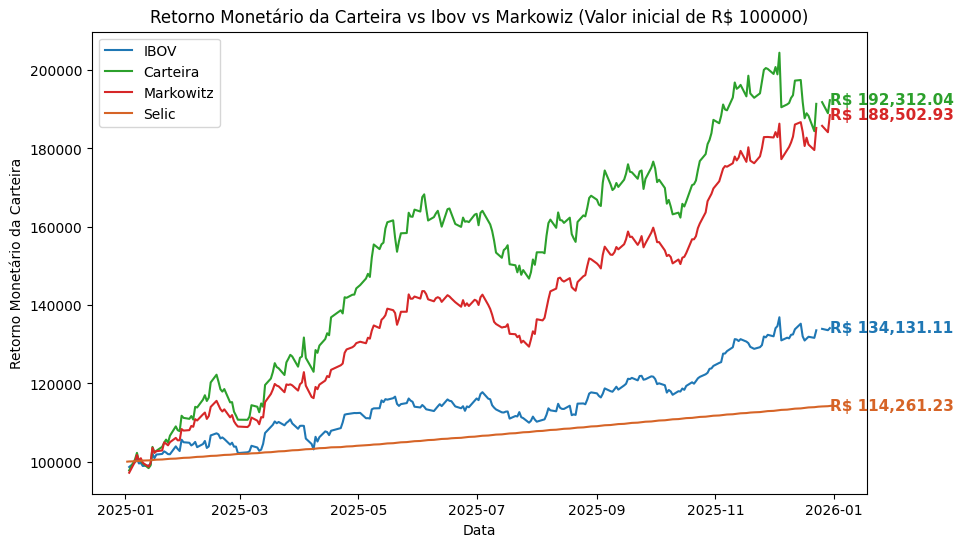

,IBOV,Carteira,Markowitz,Selic
Date,,,,
2025-01-02,NaN,NaN,NaN,100045.513000
2025-01-03,98674.713840,97810.791477,97217.022520,100091.046714
2025-01-06,99914.255983,100609.458801,100047.427600,100136.601152
2025-01-07,100864.099896,102290.819047,101756.371674,100182.176324
2025-01-08,99583.766909,100192.130149,100295.949878,100227.772238
...,...,...,...,...
2025-12-24,NaN,NaN,NaN,114072.461632
2025-12-26,133941.311134,191821.350178,185772.124506,114135.350920
2025-12-29,133602.497399,188999.285423,184139.134479,114198.274881


In [89]:
pesos = list(response_pesos['tickers_weights'].values()) 
comp = ComputandoMetricas("2025-01-01", "2025-12-31", tics_selecionados_sa, pesos, 100000)
comp.print_results()

In [60]:
"""results_tics = await run_all_tics(
    tics
    #list_tics[:10]
    )"""

'results_tics = await run_all_tics(\n    tics\n    #list_tics[:10]\n    )'

## Carteira no tempo

In [61]:
import datetime

In [62]:
def sequencia_datas(start="2015-01-01", end="2025-12-31", freq="QS"):
    data_hoje = datetime.datetime.now().strftime("%Y-%m-%d")
    periodo_datas = pd.date_range(start=start, end=data_hoje, freq=freq)
    
    datas_dict = {}
    
    for data in periodo_datas:
        novos_trimestres = pd.date_range(start=data, periods=8, freq='Q')
        data_inicio = novos_trimestres[0].strftime("%Y-%m-%d")
        data_fim = novos_trimestres[-1].strftime("%Y-%m-%d")
        
        if data_fim > data_hoje:
            data_fim = data_hoje
            datas_dict[data_inicio] = data_fim
            return datas_dict
        
        datas_dict[data_inicio] = data_fim
        
    
    return datas_dict
    

In [63]:
sequencia_datas = sequencia_datas(start="2015-01-01", end="2025-12-31", freq="QS")


In [68]:

tics = ["VALE3", "PETR4", "ITUB4", "BBDC4", "ABEV3", 
        "MGLU3", "BBAS3", "GGBR4", "RENT3", "LREN3",
        "PSSA3", "BRAP4", "VIVT3"]



tics_2 = ["VALE3", "ITUB4", "BBDC4", "ABEV3",
        "BBAS3", "GGBR4", "RENT3", "LREN3",
        "PSSA3", "B3SA3", "BBSE3", "BRAP4", 
        "VIVT3","CSNA3", "BRKM5", "CSUD3", 
        "CGAS3", "CMIG3","WEGE3", "ENBR3", 
        "EGIE3", "ELET3","PRIO3","PSSA3",
        "MDIA3", "MGLU3", "MRVE3", "NTCO3",
        "IRBR3","FIQE3","FLRY3"]

In [ ]:
# Versão otimizada das chamadas assíncronas
import asyncio
import random
import time
from asyncio import Semaphore, TimeoutError as AsyncTimeoutError
from typing import Any, Dict, List, Optional, Tuple

# Configurações de performance (ajuste conforme a API aguenta)
MAX_CONCURRENT = 5           # limite de requisições simultâneas
MAX_RETRIES = 3              # tentativas por ticker
TIMEOUT_SECONDS = 240        # timeout por ticker (s)
RETRY_DELAY_BASE = 2         # base do backoff exponencial

async def _invoke_tic(
    tic: str,
    data_inicio: str = "2023-01-01",
    data_fim: str = "2025-01-01",
) -> Optional[Dict[str, Any]]:
    """Processa um único ticker com timeout e retry exponencial."""
    err = ""
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            start = time.time()
            logger.info(f"🚀 [{attempt}/{MAX_RETRIES}] Iniciando {tic}")

            result = await asyncio.wait_for(
                graph_build.ainvoke(
                    StateClassification(  # type: ignore[arg-type]
                        {
                            "tic": tic,
                            "data_inicio": data_inicio,
                            "data_fim": data_fim,
                            "avaliacao_analise": "",
                            "description_avaliacao_analise": "",
                            "interacao": 0,
                            "classification": "Fair",
                            "analysis": "Placeholder",
                            "dados_fundamentalistas": "",
                        }
                    )
                ),
                timeout=TIMEOUT_SECONDS,
            )

            logger.info(f"✅ {tic} concluído em {time.time() - start:.1f}s")
            return result

        except AsyncTimeoutError:
            logger.warning(f"⏱️ Timeout em {tic} (>{TIMEOUT_SECONDS}s)")
        except Exception as e:  # noqa: BLE001
            err = str(e)
            logger.warning(
                f"⚠️ Erro em {tic} tentativa {attempt}/{MAX_RETRIES}: {err[:120]}"
            )

        if attempt < MAX_RETRIES:
            # backoff exponencial com jitter leve para evitar thundering herd
            delay = RETRY_DELAY_BASE ** attempt + random.uniform(0, 0.5)
            # se erro de rate limit, aumenta um pouco o descanso
            if "rate limit" in err.lower() or "429" in err:
                delay = min(delay * 2, 60)
            logger.info(f"🔄 Aguardando {delay:.1f}s antes do retry de {tic}")
            await asyncio.sleep(delay)

    logger.error(f"❌ Falha definitiva em {tic} após {MAX_RETRIES} tentativas")
    return None

async def run_all_tics(
    tics: List[str],
    data_inicio: str = "2023-01-01",
    data_fim: str = "2025-01-01",
    max_concurrent: int = MAX_CONCURRENT,
) -> Dict[str, Optional[Dict[str, Any]]]:
    """Processa múltiplos tickers em paralelo com controle de concorrência."""
    start_total = time.time()
    total_tics = len(tics)
    semaphore = Semaphore(max_concurrent)
    completed = 0
    failed = 0
    results: Dict[str, Optional[Dict[str, Any]]] = {}

    async def runner(tic: str) -> Tuple[str, Optional[Dict[str, Any]]]:
        nonlocal completed, failed
        async with semaphore:
            result = await _invoke_tic(tic, data_inicio, data_fim)
            completed += 1
            failed += int(result is None)
            progress = (completed / total_tics) * 100
            logger.info(
                f"📈 Progresso: {completed}/{total_tics} ({progress:.1f}%) | "
                f"Sucessos: {completed - failed} | Falhas: {failed}"
            )
            return tic, result

    tasks = [asyncio.create_task(runner(tic)) for tic in tics]

    for coro in asyncio.as_completed(tasks):
        try:
            tic, result = await coro
            results[tic] = result
        except Exception as e:  # noqa: BLE001
            logger.error(f"❌ Exceção não tratada em execução: {e}")
            failed += 1

    elapsed_total = time.time() - start_total
    success = total_tics - failed
    logger.info(
        f"\n{'='*40}\n"
        f"📊 Resumo final\n"
        f"⏱️ Tempo total: {elapsed_total:.1f}s ({elapsed_total/60:.1f} min)\n"
        f"✅ Sucessos: {success}/{total_tics}\n"
        f"❌ Falhas: {failed}/{total_tics}\n"
        f"🚀 Throughput: {total_tics/(elapsed_total/60):.2f} tics/min\n"
        f"{'='*40}"
    )

    return results


results = await run_all_tics(tics)



In [ ]:
import time
from IPython.display import display, Markdown
results_dict = {}
results_dict_marcowitz = {}
for data_inicio, data_fim in sequencia_datas.items():
    display(Markdown(f"## Iniciando o processo para o periodo de {data_inicio} a {data_fim}"))
    try:
        start_time = time.time()
        results_tics = await run_all_tics(
            tics,
            data_inicio=data_inicio,
            data_fim=data_fim
            )
        
        logger.info(f"Avaliação das acoes foi concluído para {data_inicio} a {data_fim}")    
        
        dados_markdown = transformando_data_frame_para_markdown(results_tics)
        
        
        correlacao_tics = correlacao(list(results_tics.keys()))
        
        response_pesos = await graph_weights_build.ainvoke(
            StateCarteira({
            "justification" : "",
            "avaliacao_acoes": dados_markdown,
            "correlacao_acoes": correlacao_tics,
            "interacao" : 0,
            "tics" : tics
            }))
        
        results_dict[f"{data_inicio} a {data_fim}"] = response_pesos
        
        logger.info(f"O peso foi calculado para {data_inicio} a {data_fim}") 
        
        tics_selecionados = list(response_pesos['tickers_weights'].keys()) 
        
        pesos = list(response_pesos['tickers_weights'].values()) 
        
        pesos_pd = pd.DataFrame(response_pesos['tickers_weights'], index=["Carteira"]).T
        
        display(pesos_pd.style.set_caption("Pesos da Carteira").background_gradient(cmap="Blues"))
        
        tics_selecionados = [tics if ".SA" in tics else tics + ".SA" for tics in tics_selecionados]
        
        data_now = datetime.datetime.now().strftime("%Y-%m-%d")
        
        comp = ComputandoMetricas(data_fim, data_now, tics_selecionados, pesos, 1000)
        
        weights_markowitz, _ = comp.computando_marcowitz()
        
        computando_marcowitz = weights_markowitz.iloc[-1].to_dict()
        
        results_dict_marcowitz[f"{data_inicio} a {data_fim}"] = computando_marcowitz
        
        comp.print_results()

        logger.info(f"Metricas foram calculadas para {data_inicio} a {data_fim}")
        
        end_time = time.time()
        execution_time = end_time - start_time
        logger.info(f"Tempo de execução para {data_inicio} a {data_fim}: {execution_time:.2f} segundos")
        
    except Exception as e:
        logger.error(f"Erro ao processar {data_inicio} a {data_fim}: {e}")

In [183]:
with open("results_dict_2.json", "w") as f:
    json.dump(results_dict, f)
    
with open("results_marcowitz.json", "w") as f:
    json.dump(results_dict_marcowitz, f)

In [2]:
import json
with open("results_dict.json", "r") as f:
    results_dict = json.load(f)

In [3]:
results_dict

{'2015-03-31 a 2016-12-31': {'tickers_weights': {'ABEV3.SA': 20.0,
   'GGBR4.SA': 15.0,
   'ITUB4.SA': 10.0,
   'MGLU3.SA': 5.0,
   'PETR4.SA': 20.0,
   'RENT3.SA': 20.0,
   'VIVT3.SA': 10.0},
  'justification': 'The portfolio combines high-quality stocks from sectors with strong fundamentals and low correlation. ABEV3 is chosen for its stable margins and manageable leverage, contributing to a solid return/risk profile. GGBR4 and ITUB4 offer diversification benefits despite their fair classification. Fair-class RENT3 and PETR4 are included for their moderate correlation to other assets. MGLU3 and VIVT3 provide additional diversification. Risk mitigation includes a weighted average correlation of 0.4 and limited exposure to poorly rated assets. The total weight sums to 100%.',
  'analise_avaliador_weights': 'Alright, let\'s tackle this evaluation step by step. First, I need to understand the problem at hand. The user provided a proposed portfolio allocation but had an error where the to

In [78]:
tics_modelo =["VALE3.SA", "PETR4.SA", "ITUB4.SA", "BBDC4.SA", "ABEV3.SA", "MGLU3.SA", "BBAS3.SA", "GGBR4.SA", "RENT3.SA", "LREN3.SA", "PSSA3.SA", "BRAP4.SA", "VIVT.SA" ,"OUTO3"]

tirando_sa = [tic.split(".")[0] for tic in tics_modelo]

tirando_sa

['VALE3',
 'PETR4',
 'ITUB4',
 'BBDC4',
 'ABEV3',
 'MGLU3',
 'BBAS3',
 'GGBR4',
 'RENT3',
 'LREN3',
 'PSSA3',
 'BRAP4',
 'VIVT',
 'OUTO3']

In [ ]:
#tics_modelo = list(results_dict['2015-03-31 a 2016-12-31']['tickers_weights'].keys())

tirando_sa = [tic.split(".")[0] for tic in tics_modelo]

tics_selecionados = [tic for tic in tirando_sa if tic not in tics]



if tics_selecionados:
    tics_string = ",".join(tics_selecionados)
    print(tics_string)

VIVT,OUTO3


In [82]:
tics_string

'VIVT,OUTO3'

In [ ]:
results_dict

## Tool metrics

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

def get_ibov_tickers_from_statusinvest():
    url = "https://statusinvest.com.br/indices/ibovespa"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    }
    r = requests.get(url, headers=headers)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    # A página exibe os tickers dentro de elementos com classe .ticker (como você mencionou)
    tickers = []
    for elem in soup.select(".main-list .ticker"):
        t = elem.get_text(strip=True)
        # Alguns podem ter espaço ou texto adicional — limpar
        if t:
            tickers.append(t + ".SA")  # se quiser no formato Yahoo Finance

    tickers = list(dict.fromkeys(tickers))  # remove duplicados preservando ordem
    return tickers

In [ ]:
tickers = get_ibov_tickers_from_statusinvest()

In [ ]:
tickers

In [ ]:
from datetime import datetime

def validate_date(date_str: str, field_name):
    try:
            datetime.strptime(date_str, "%Y-%m-%d")
    except ValueError:
        raise ValueError(
            f"Erro: '{field_name}' deve estar no formato YYYY-MM-DD. "
            f"Valor recebido: {date_str}"
        )

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
from typing import List, Optional

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

#from src.utils import validate_date

def fetch_data(tickers: List[str], start: str, end: Optional[str] = None) -> pd.DataFrame:
    if start is None:
        raise ValueError("O parâmetro 'start' é obrigatório.")
    
    validate_date(start, "start")

    if end is None:
        end = datetime.today().strftime("%Y-%m-%d")
    else:
        validate_date(end, "end")

    if start >= end:
        raise ValueError(f"A data inicial ({start}) deve ser anterior à data final ({end.strftime('%Y-%m-%d')}).")
    
    df = yf.download(tickers, start=start, end=end, progress=False)["Close"]

    df = df.dropna(how="all", axis=1)

    if df.empty:
        raise ValueError("Nenhum dado retornado. Verifique os tickers ou intervalo de datas.")
    
    return df

In [ ]:
data_precos = fetch_data(tics_selecionados, "2025-01-01")

In [ ]:
data_precos

Ticker,ABEV3.SA,EGIE3.SA,FLRY3.SA,ITUB4.SA,MDIA3.SA,PSSA3.SA,VIVT3.SA,WEGE3.SA
Date,,,,,,,,
2025-01-02,11.156353,24.170660,11.132780,25.891182,19.080801,34.614265,22.329082,51.778976
2025-01-03,10.896679,24.136482,11.058747,25.255976,19.061340,33.228546,22.234186,51.523617
2025-01-06,10.858209,24.109140,11.364135,26.390881,19.547846,34.566479,22.651730,51.533436
2025-01-07,11.098648,24.321045,11.327118,26.678846,19.820288,35.359684,23.116728,52.564693
2025-01-08,10.983237,24.027113,11.206814,26.246902,19.421349,34.891407,22.419231,52.260231
...,...,...,...,...,...,...,...,...
2025-11-26,13.670000,31.692858,15.293604,40.832542,26.230000,47.509998,35.110001,44.400002
2025-11-27,13.720000,31.719999,15.411854,40.692600,25.639999,47.500000,35.250000,44.049999
2025-11-28,13.860000,30.639999,15.815871,41.622204,25.780001,47.189999,35.430000,44.250000


In [ ]:
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize

def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

In [ ]:
#data_precos.drop(columns=["AURE3.SA", "EMBJ3.SA", "MOTV3.SA", "NATU3.SA"], inplace=True, axis=1) 

In [ ]:
weights_markowitz, markowitz_cr = markowitz_opt(data_precos.pct_change().dropna())

In [ ]:
weights_markowitz

Ticker,ABEV3.SA,EGIE3.SA,FLRY3.SA,ITUB4.SA,MDIA3.SA,PSSA3.SA,VIVT3.SA,WEGE3.SA
Date,,,,,,,,
2025-01-03,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534
2025-01-06,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534
2025-01-07,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534
2025-01-08,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534
2025-01-09,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534
...,...,...,...,...,...,...,...,...
2025-11-26,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534
2025-11-27,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534
2025-11-28,0.181494,0.174263,0.070456,0.125695,0.067839,0.134653,0.143066,0.102534


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        dr = daily_returns(p)
        metrics[col] = {
            "ann_vol": annualized_volatility(dr),
            "ann_mean_ret": annualized_mean_return(dr),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(dr)
        }
    return pd.DataFrame(metrics).T

In [ ]:
data_precos

Ticker,ABEV3.SA,EGIE3.SA,FLRY3.SA,ITUB4.SA,MDIA3.SA,PSSA3.SA,VIVT3.SA,WEGE3.SA
Date,,,,,,,,
2025-01-02,11.156353,24.170660,11.132780,25.891182,19.080801,34.614265,22.329082,51.778976
2025-01-03,10.896679,24.136482,11.058747,25.255976,19.061340,33.228546,22.234186,51.523617
2025-01-06,10.858209,24.109140,11.364135,26.390881,19.547846,34.566479,22.651730,51.533436
2025-01-07,11.098648,24.321045,11.327118,26.678846,19.820288,35.359684,23.116728,52.564693
2025-01-08,10.983237,24.027113,11.206814,26.246902,19.421349,34.891407,22.419231,52.260231
...,...,...,...,...,...,...,...,...
2025-11-26,13.670000,31.692858,15.293604,40.832542,26.230000,47.509998,35.110001,44.400002
2025-11-27,13.720000,31.719999,15.411854,40.692600,25.639999,47.500000,35.250000,44.049999
2025-11-28,13.860000,30.639999,15.815871,41.622204,25.780001,47.189999,35.430000,44.250000


In [ ]:
metrics = compute_metrics(data_precos)

In [ ]:
metrics

,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
ABEV3.SA,0.214806,0.270696,0.281834,-0.172151,-0.039195,1.637132,1.356853
EGIE3.SA,0.223465,0.298937,0.316000,-0.196846,-0.031630,1.605321,1.424516
FLRY3.SA,0.299766,0.430314,0.473106,-0.126691,-0.032529,3.734323,1.907565
ITUB4.SA,0.202367,0.554286,0.707010,-0.091983,-0.021750,7.686309,3.069259
MDIA3.SA,0.378320,0.386115,0.372590,-0.151812,-0.050648,2.454286,1.114146
PSSA3.SA,0.245874,0.388262,0.431414,-0.192597,-0.033425,2.239976,1.529723
VIVT3.SA,0.234635,0.521129,0.639382,-0.077791,-0.024331,8.219271,2.074010
WEGE3.SA,0.314899,-0.087901,-0.129534,-0.375549,-0.102831,-0.344918,-0.244838


## Todo lists

In [ ]:
WRITE_TODOS_DESCRIPTION = """Create and manage structured task lists for tracking progress through complex workflows.

## When to Use
- Multi-step or non-trivial tasks requiring coordination
- When user provides multiple tasks or explicitly requests todo list  
- Avoid for single, trivial actions

## Structure
- Maintain one list containing multiple todo objects (content, status, id)
- Use clear, actionable content descriptions
- Status must be: pending, in_progress, or completed

## Best Practices  
- Only one in_progress task at a time
- Mark completed immediately when task is fully done
- Always send the full updated list when making changes
- Prune irrelevant items to keep list focused

## Progress Updates
- Call TodoWrite again to change task status or edit content
- Reflect real-time progress; don't batch completions  
- If blocked, keep in_progress and add new task describing blocker

## Parameters
- todos: List of TODO items with content and status fields

## Returns
Updates agent state with new todo list."""

In [ ]:
"""TODO management tools for task planning and progress tracking.

This module provides tools for creating and managing structured task lists
that enable agents to plan complex workflows and track progress through
multi-step operations.
"""

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
import operator
from typing import TypedDict, Literal, List, Annotated
from langchain_core.messages import BaseMessage

class Todo(TypedDict):
    """A structured task item for tracking progress through complex workflows.

    Attributes:
        content: Short, specific description of the task
        status: Current state - pending, in_progress, or completed
    """

    content: str
    status: Literal["pending", "in_progress", "completed"]
    

class DeepInvestiment(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    todos: list[Todo]


@tool(description=WRITE_TODOS_DESCRIPTION,parse_docstring=True)
def write_todos(
    todos: list[Todo], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Args:
        todos: List of Todo items with content and status
        tool_call_id: Tool call identifier for message response

    Returns:
        Command to update agent state with new TODO list
    """
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list to {todos}", tool_call_id=tool_call_id)
            ],
        }
    )


@tool(parse_docstring=True)
def read_todos(
    state: Annotated[DeepInvestiment, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> str:
    """Read the current TODO list from the agent state.

    This tool allows the agent to retrieve and review the current TODO list
    to stay focused on remaining tasks and track progress through complex workflows.

    Args:
        state: Injected agent state containing the current TODO list
        tool_call_id: Injected tool call identifier for message tracking

    Returns:
        Formatted string representation of the current TODO list
    """
    todos = state.get("todos", [])
    if not todos:
        return "No todos currently in the list."

    result = "Current TODO List:\n"
    for i, todo in enumerate(todos, 1):
        status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
        emoji = status_emoji.get(todo["status"], "❓")
        result += f"{i}. {emoji} {todo['content']} ({todo['status']})\n"

    return result.strip()

In [ ]:
TODO_USAGE_INSTRUCTIONS = """Based upon the user's request:
1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.
2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan. 
3. Reflect on what you've done and the TODO.
4. Mark you task as completed, and proceed to the next TODO.
5. Continue this process until you have completed all TODOs.

IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY user request.
IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have to keep track of.
"""

In [ ]:
prompt_agent_investimento = """
<Task>
You are whose mission is to help the user .
Context: today's date is {date}. Assume the user speaks Portuguese unless otherwise specified.

<Capabilities / Tools>
You have access to the following tools:

1. **write_todos** — Manage or update the agent's TODO list for task planning and progress tracking.
   • Limit: up to **3 calls per session** (initial plan + mid-update + final review).

2. **read_todos** — Read the current TODO list to maintain context and focus.
   • Limit: up to **5 calls per session** (use only when switching context or resuming work).

3. **web_search** — Retrieve verified external information (APIs, frameworks, recent updates).
   • Limit: based on complexity level:
     - Simple tasks → **max 1 call**
     - Normal tasks → **max 2 calls**
     - Complex/research-heavy tasks → **max 3 calls**
   • Never exceed 3 total web_search calls in one user task.

4. **think_tool** — Reflect after each search or major step; summarize findings, identify gaps, and plan next actions.
   • Mandatory after every web_search call.
   • Limit: **equal to number of web_search calls + 2** (for initial and final reflections).



<Show Your Thinking>
After each **web_search**, use **think_tool** to summarize:
- Key findings
- Missing information
- Whether another search is needed or if the task can proceed
- How the new info affects the plan



</prompt_agent_code>
"""


In [ ]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents import create_agent
from tavily import TavilyClient
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
import sys
from datetime import datetime


load_dotenv()

tavily_client = TavilyClient()

@tool(parse_docstring=True)
def web_search(query: str, max_results: int = 5, include_images: bool = False) -> list[dict[str, str]]:
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.
        max_results: The maximum number of search results to return.
        include_images: Whether to include images in the search results.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    params = {}
    api_key = os.getenv("TAVILY_API_KEY")
    if not api_key:
        raise ValueError("TAVILY_API_KEY not found in environment variables.")
    params['api_key'] = api_key

    #client = TavilyClient(api_key)

    api_base_url = os.getenv("DLAI_TAVILY_BASE_URL")
    if api_base_url:
        params['api_base_url'] = api_base_url

    client = TavilyClient(api_key=api_key, api_base_url=api_base_url)

    try:
        response = client.search(
            query=query,
            max_results=max_results,
            include_images=include_images
        )

        results = []
        for r in response.get("results", []):
            results.append({
                "title": r.get("title", ""),
                "content": r.get("content", ""),
                "url": r.get("url", "")
            })

        if include_images:
            for img_url in response.get("images", []):
                results.append({"image_url": img_url})

        return results

    except Exception as e:
        return [f'An Error occurred: {e} with the Tavily API. Please try again later.']


@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"


def get_today_str() -> str:
    """Get current date in a human-readable format."""
    if sys.platform.startswith("win"):
        return datetime.now().strftime("%a %b %#d, %Y")
    else:
        return datetime.now().strftime("%a %b %-d, %Y")

model = ChatNVIDIA(
    model="qwen/qwen3-next-80b-a3b-instruct",
)

tools = [write_todos, web_search, read_todos,think_tool]

current_date = get_today_str()
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Create agent
agent = create_agent(
    model,
    tools,
    system_prompt=TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "\n\n"
    + prompt_agent_investimento.format(date=get_today_str())
    ,
    state_schema=DeepInvestiment,
    #checkpointer=MemorySaver()
    
)



In [ ]:
config = {"configurable": {"user_id": "1", "thread_id": "1"}}

In [ ]:
from langchain_core.messages import HumanMessage
rodar = True
if rodar:

    result = agent.invoke(
        {
            "messages": 
                [HumanMessage(role="user",
                            content=""" 
                            Tenho 100000 para investir, monte uma carteira diversificada com ações do Ibovespa.
                                """)],
            
        }, #config=config
    )


In [ ]:
from utils import format_messages
if rodar:
    format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│                                                                                                                 │
│                             Tenho 100000 para investir, monte uma carteira diversificada com ações do Ibovespa. │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Pesquisar as melhores ações do Ibovespa para diversificação de carteira com base em capital   │
│ de R$100.000",                                                                                                  │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Identificar setores estratégicos e ações com bom desempenho histórico e baixa correlação      │
│ entre si",                                                                                                      │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Montar uma carteira diversificada com alocação de capital por ação, considerando liquidez e   │
│ risco",                                                                                                         │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Revisar e ajustar a carteira com base em critérios de diversificação e recomendações atuais", │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_f6cd41187dff4251aaa5a87b                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Pesquisar as melhores ações do Ibovespa para diversificação de carteira com  │
│ base em capital de R$100.000', 'status': 'pending'}, {'content': 'Identificar setores estratégicos e ações com  │
│ bom desempenho histórico e baixa correlação entre si', 'status': 'pending'}, {'content': 'Montar uma carteira   │
│ diversificada com alocação de capital por ação, considerando liquidez e risco', 'status': 'pending'},           │
│ {'content': 'Revisar e ajustar a carteira com base em critérios de diversificação e recomendações atuais',      │
│ 'status': 'pending'}]                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "melhores ações Ibovespa diversificação carteira 2025 setores estratégicos liquidez",                │
│   "max_results": 5                                                                                              │
│ }                                                                                                               │
│    ID: call_3555d7a0d48147ed86327bdb                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ [{"title": "Carteira Recomendada de Ações – Janeiro 2025", "content": "No ano de 2025 a carteira apresenta      │
│ rentabilidade negativa de -26,83% contra uma baixa de -10,36% do Ibovespa. Em relação ao mês de dezembro,",     │
│ "url":                                                                                                          │
│ "https://analisa.genialinvestimentos.com.br/carteiras-recomendadas/renda-variavel/carteira-recomendada-de-acoes │
│ -janeiro-2025"}, {"title": "8 Ações Recomendadas para investir em janeiro de 2025", "content": "A seleção busca │
│ diversificação entre setores e perfis de risco, visando retornos consistentes no longo prazo para quem busca    │
│ investir em ações.", "url":                                                                                     │
│ "https://master.clear.com.br/carteiras/carteiras-acoes-recomendadas-janeiro-2025/"}, {"title": "Diversificar a  │
│ carteira é uma das estratégias mais ...", "content": "Agora, ouro, Selic, renda fixa e setores estratégicos     │
│ contam com novos benchmarks oficiais, ampliando as referências para quem investe.", "url":                      │
│ "https://www.instagram.com/p/DQUpGcGiuAj/"}, {"title": "Melhores investimentos de 2025: o que Analistas da      │
│ ...", "content": "Assim, para investidores que possuam o perfil de risco adequado e que desejem uma exposição a │
│ um único ativo para acompanhar o desempenho da Bolsa brasileira no longo prazo, o ETF BOVA11 pode ser uma       │
│ alternativa interessante de alocação em 2025. Os Fundos de Investimento Multimercados (FIM) são aqueles que     │
│ apresentam uma política de investimento voltada para diversos fatores de risco, podendo **aplicar em vários     │
│ mercados, como ações, cmbio, Renda Fixa e outros, podendo incluir derivativos para alavancagem**. >             │
│ Diversificar o patrimônio globalmente é uma estratégia utilizada por grandes investidores a fim de melhorar o   │
│ perfil de risco e retorno das carteiras de investimentos.", "url":                                              │
│ "https://blog.toroinvestimentos.com.br/investimentos/melhores-investimentos/"}, {"title": "Veja as 14 ações do  │
│ Ibovespa B3 e do Small Caps que ...", "content": "O destaque fica para as ações da Cogna (COGN3), com alta de   │
│ 240,16%, “impulsionada pela reestruturação financeira e pela retomada dos resultados", "url":                   │
│ "https://borainvestir.b3.com.br/tipos-de-investimentos/renda-variavel/acoes/veja-as-14-acoes-do-ibovespa-b3-e-d │
│ o-small-caps-que-dobraram-de-valor-em-2025/"}]                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: call_51ffb7fd8dec44caa81c876c                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Current TODO List:                                                                                              │
│ 1. ⏳ Pesquisar as melhores ações do Ibovespa para diversificação de carteira com base em capital de R$100.000  │
│ (pending)                                                                                                       │
│ 2. ⏳ Identificar setores estratégicos e ações com bom desempenho histórico e baixa correlação entre si         │
│ (pending)                                                                                                       │
│ 3. ⏳ Montar uma carteira diversificada com alocação de capital por ação, considerando liquidez e risco         │
│ (pending)                                                                                                       │
│ 4. ⏳ Revisar e ajustar a carteira com base em critérios de diversificação e recomendações atuais (pending)     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Pesquisar as melhores ações do Ibovespa para diversificação de carteira com base em capital   │
│ de R$100.000",                                                                                                  │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Identificar setores estratégicos e ações com bom desempenho histórico e baixa correlação      │
│ entre si",                                                                                                      │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Montar uma carteira diversificada com alocação de capital por ação, considerando liquidez e   │
│ risco",                                                                                                         │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Revisar e ajustar a carteira com base em critérios de diversificação e recomendações atuais", │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_a55b497382aa4680b6432abb                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Pesquisar as melhores ações do Ibovespa para diversificação de carteira com  │
│ base em capital de R$100.000', 'status': 'completed'}, {'content': 'Identificar setores estratégicos e ações    │
│ com bom desempenho histórico e baixa correlação entre si', 'status': 'completed'}, {'content': 'Montar uma      │
│ carteira diversificada com alocação de capital por ação, considerando liquidez e risco', 'status':              │
│ 'in_progress'}, {'content': 'Revisar e ajustar a carteira com base em critérios de diversificação e             │
│ recomendações atuais', 'status': 'pending'}]                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Com base na análise realizada e nas recomendações de grandes corretoras como o BTG Pactual, aqui está uma       │
│ proposta de **carteira diversificada de ações do Ibovespa para R$100.000**, alinhada aos critérios de liquidez, │
│ diversificação setorial e baixa correlação entre os ativos:                                                     │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 📊 **Carteira Diversificada de Ações do Ibovespa – R$100.000 (2025)**                                       │
│                                                                                                                 │
│ | Ação | Empresa | Setor | Alocação | Valor (R$) | Justificativa |                                              │
│ |------|---------|-------|----------|------------|----------------|                                             │
│ | **BOVA11** | ETF Ibovespa | Índice (Diversificado) | **40%** | **R$40.000** | Base da carteira. Oferece       │
│ exposição imediata a todos os principais ativos do Ibovespa, reduzindo risco individual e garantindo liquidez.  │
│ Ideal para investidores que buscam segurança e baixa manutenção. |                                              │
│ | **PETR4** | Petrobras | Energia | **15%** | **R$15.000** | Líder do índice, alta liquidez, beneficiada por    │
│ preços internacionais de petróleo e política de distribuição de dividendos. Correlação moderada com bancos e    │
│ consumo. |                                                                                                      │
│ | **VALE3** | Vale | Mineração | **12%** | **R$12.000** | Expõe a carteira ao ciclo de commodities (ferro e     │
│ nickel). Baixa correlação com bancos e consumo, ampliando diversificação. Alta liquidez. |                      │
│ | **BBDC4** | Bradesco | Bancário | **10%** | **R$10.000** | Um dos maiores bancos do Brasil, com forte         │
│ rentabilidade e dividend yield atraente. O setor bancário é o maior peso do Ibovespa, mas não deve ser          │
│ superexposto. |                                                                                                 │
│ | **ITSA4** | Itaúsa | Conglomerado Financeiro | **8%** | **R$8.000** | Holding do Itaú Unibanco, oferece       │
│ exposição indireta ao setor bancário com menor volatilidade e boa gestão de dividendos. |                       │
│ | **B3SA3** | B3 | Infraestrutura Financeira | **8%** | **R$8.000** | A bolsa brasileira. Beneficiada pelo      │
│ aumento da atividade de negociação e pela crescente participação de investidores individuais. Recomendada pelo  │
│ BTG Pactual em 2025. |                                                                                          │
│ | **CSNA3** | CVRD (Vale) | Mineração | **3%** | **R$3.000** | Alternativa à VALE3 para diversificação dentro   │
│ do mesmo setor, com menor peso para evitar concentração. |                                                      │
│ | **ABEV3** | Ambev | Consumo | **4%** | **R$4.000** | Líder no setor de bebidas, com forte margem e presença   │
│ global. Baixa correlação com setores cíclicos como energia e mineração. |                                       │
│ | **CMIG4** | Cemig | Energia Elétrica | **2%** | **R$2.000** | Exposição ao setor de energia elétrica, com     │
│ regulamentação estável e dividendos consistentes. Diversifica dentro do setor de energia. |                     │
│                                                                                                                 │
│ > ✅ **Total: R$100.000 | 9 ativos + ETF**               